Test czy działa python i biblioteki ML

In [1]:
import tensorflow as tf
import torch 
import sklearn

print(tf.__version__)
print(torch.__version__)
print(sklearn.__version__)

2.20.0
2.9.1+cpu
1.7.2


Test prostej regresji liniowej na zbiorze danych ssaków
Import potrzebnych modułów

In [2]:
#@title Przydatne moduły do zaimportowania

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Nice printing
import pprint

# Data processing
import numpy as np
import pandas as pd

# Data transformation
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from numpy import log

# Data preparation for learning, model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
import sklearn.model_selection as ms

# Linear regression
from sklearn import linear_model
from sklearn.linear_model import Ridge, Lasso

# Processing pipelining
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline

# Quality indicators
from sklearn import metrics

Zbiór danych ssaków

In [3]:
mammals=pd.read_csv("mammals.csv")
body_data=mammals[['body']]

print(body_data)
print(body_data.shape)

brain_data=mammals[['brain']]
print(brain_data)
print(brain_data.shape)


       body
0     3.385
1     0.480
2     1.350
3   465.000
4    36.330
..      ...
57  160.000
58    0.900
59    1.620
60    0.104
61    4.235

[62 rows x 1 columns]
(62, 1)
    brain
0    44.5
1    15.5
2     8.1
3   423.0
4   119.5
..    ...
57  169.0
58    2.6
59   11.4
60    2.5
61   50.4

[62 rows x 1 columns]
(62, 1)


Regresja liniowa za pomocą scikit-learn

Współczynnik [[0.96649637]]
wyraz wolny= [91.00439621]


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Współczynnik [[0.75168594]]
wyraz wolny= [2.13478868]


c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


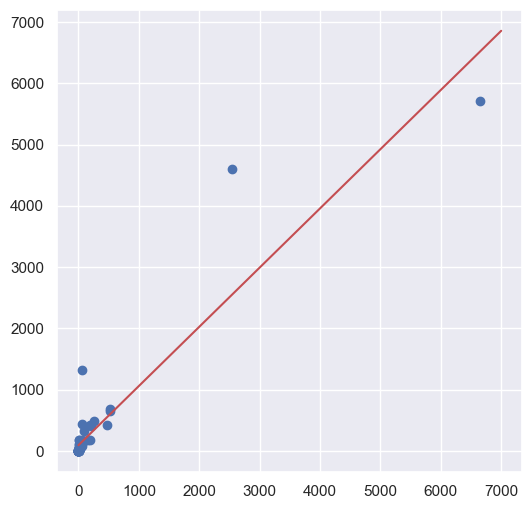

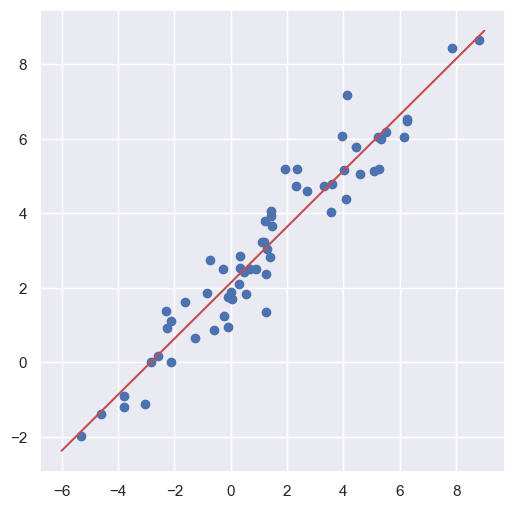

In [4]:
from sklearn import linear_model

sk_regr=linear_model.LinearRegression()
sk_regr.fit(body_data,brain_data)
print(f'Współczynnik {sk_regr.coef_}')
print(f'wyraz wolny= {sk_regr.intercept_}')

display(sk_regr)

range1=np.linspace(0,7000,10)
new_body=range1[:,np.newaxis]

brain_pred=sk_regr.predict(new_body)
plt.figure(figsize=(6,6))
plt.scatter(mammals['body'],mammals['brain'])
plt.plot(new_body,brain_pred,'r', label="Linia regresji")

mammals['log_body']=np.log(mammals['body'])
mammals['log_brain']=np.log(mammals['brain'])

log_body=mammals[['log_body']]
log_brain=mammals[['log_brain']]


model=linear_model.LinearRegression()
model.fit(log_body,log_brain)
print(f'Współczynnik {model.coef_}')
print(f'wyraz wolny= {model.intercept_}')

range2=np.linspace(-6,9,10)
new_body_2=range2[:,np.newaxis]

brain_log_pred=model.predict(new_body_2)
plt.figure(figsize=(6,6))
plt.scatter(mammals['log_body'],mammals['log_brain'])
plt.plot(new_body_2,brain_log_pred,'r', label="Linia regresji")
